# Bitcoin: Warp Regression on a Single Macro Cycle

On the surface, Bitcoin looks like an easy forecasting problem. Everyone who follows it can point to the ~4-year halving cycle: boom, crash, quiet accumulation, repeat. Ask exactly when the next peak lands, though, and it gets vague fast. The cycles don't repeat on a fixed schedule: 2011 to 2013 to 2017 to 2021 to 2024 are all "about four years apart", but the actual spacing wanders by many months each time. Standard seasonality tools assume a fixed period, so they have nowhere to put that wander, and I'm not aware of a canonical, off-the-shelf method that answers "here's a roughly periodic series, tell me when the next cycle peaks and how confident you are" despite how simple the question sounds out loud.

That's exactly the gap warp regression is built for. Last stop on the tour: the [synthetic notebook](WarpDifferentiable.ipynb) introduced the method, [Lynx](LynxForecast.ipynb) showed it working on real, noisy, annual data with two competing cycles. Now: daily Bitcoin closing prices, a series with basically one dominant story (the ~4-year halving cycle) riding on top of a trend that's grown by several orders of magnitude.

A few things make Bitcoin a genuinely different test case from Lynx:

- **Daily, not annual data.** Thousands of observations instead of a hundred, so the warp path has a lot more freedom (14 knots vs 8, more room for the offset to wander day to day).
- **A strong trend dominates the level.** We fit a log-trend first and warp the *residual* cycle around it, rather than warping the raw series.
- **The cycle count is known.** Bitcoin's halving-driven boom/bust pattern has produced five recognisable macro peaks (2011, 2013, 2017, 2021, 2024). We pin the sine's phase and frequency directly to those, rather than grid-searching blind.
- **Residual MA layer:** after the warp fit, a simple moving-average residual correction is folded into the holdout and 5-year forecasts.

### The model

$$y_t = C + B\log(t_{\text{idx}} - z) + f(t)\cdot\big(1 + d(1-t)\big)\cdot\mathrm{warp}\big(\sin(2\pi\omega t + \phi)\big)$$

where $y_t = \log(\text{price}_t)$. In words: a log-trend term, plus a warped macro sine whose amplitude is allowed to taper over time via a learnable envelope $1 + d(1-t)$ (the boom-bust swings were relatively larger early in Bitcoin's history).

### Recap: the dual objective

Same training rule as the last two notebooks: `fit_lambda` ($\lambda$) trades off fit quality against warp plausibility:

```
loss = λ·obj_err − (1−λ)·obj_time        (λ = 0.5 here, same as the other examples)
```

- **Holdout split:** last `TEST_DAYS = 365` observations held out.
- **Start-anchored warp:** offset pinned to 0 at the train start; free to wander toward the train end (and into the forecast).
- **Endpoint presize:** phase and time-scale are chosen so the *first and last* macro peaks land exactly on sine crests (five lobes across the training window). This is what lets us skip a blind frequency search.
- **Forecast:** start-pinned stochastic warp paths (terminal kick + future RW) give terror and combined 95% bands, with a residual MA layer on top.


In [1]:

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from warp_regression import (
    analyze_log_trend,
    interval_coverage,
    per_index_rw_sigma,
    plot_forecast_bands,
    plot_warp_offset,
    prefit,
    stored_path_offset_numpy,
)
from warp_regression.readouts import log_trend_sine as btc


## Step 1: load the full daily series

We use the complete blockchain.info daily USD close (cached locally, no date trimming). The warp learns on the full history; a 365-day holdout at the end is where we'll actually judge it.


Observations: 5771
Date range: 2010-08-18 to 2026-06-05


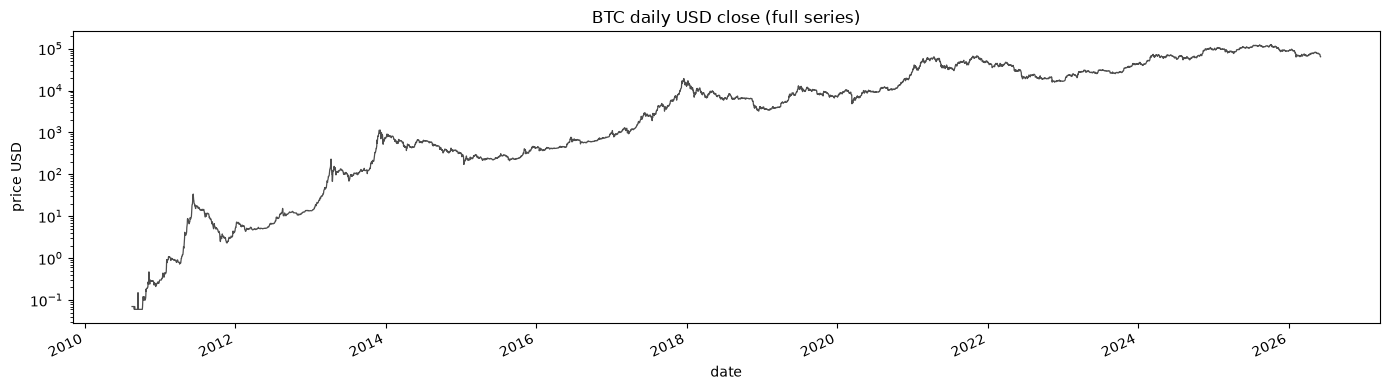

In [2]:
df = btc.fetch_bitcoin_daily()
dates = pd.DatetimeIndex(pd.to_datetime(df["date"]))
price = df["price_usd"].to_numpy(dtype=np.float64)
n = len(price)

print(f"Observations: {n}")
print(f"Date range: {dates[0].date()} to {dates[-1].date()}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.semilogy(dates, price, color="0.3", lw=0.9)
ax.set_title("BTC daily USD close (full series)")
ax.set_xlabel("date")
ax.set_ylabel("price USD")
btc.format_date_axis(ax, dates)
fig.tight_layout()
plt.show()


## Step 2: work in log space

$$y = \log(\text{price})$$

Bitcoin's price has grown across several orders of magnitude, and its swings are multiplicative (a "50% drawdown" means the same thing whether price is $100 or $60,000). Log-price puts that on an additive scale, which is what the warp model (and honestly, most time series models) expects.


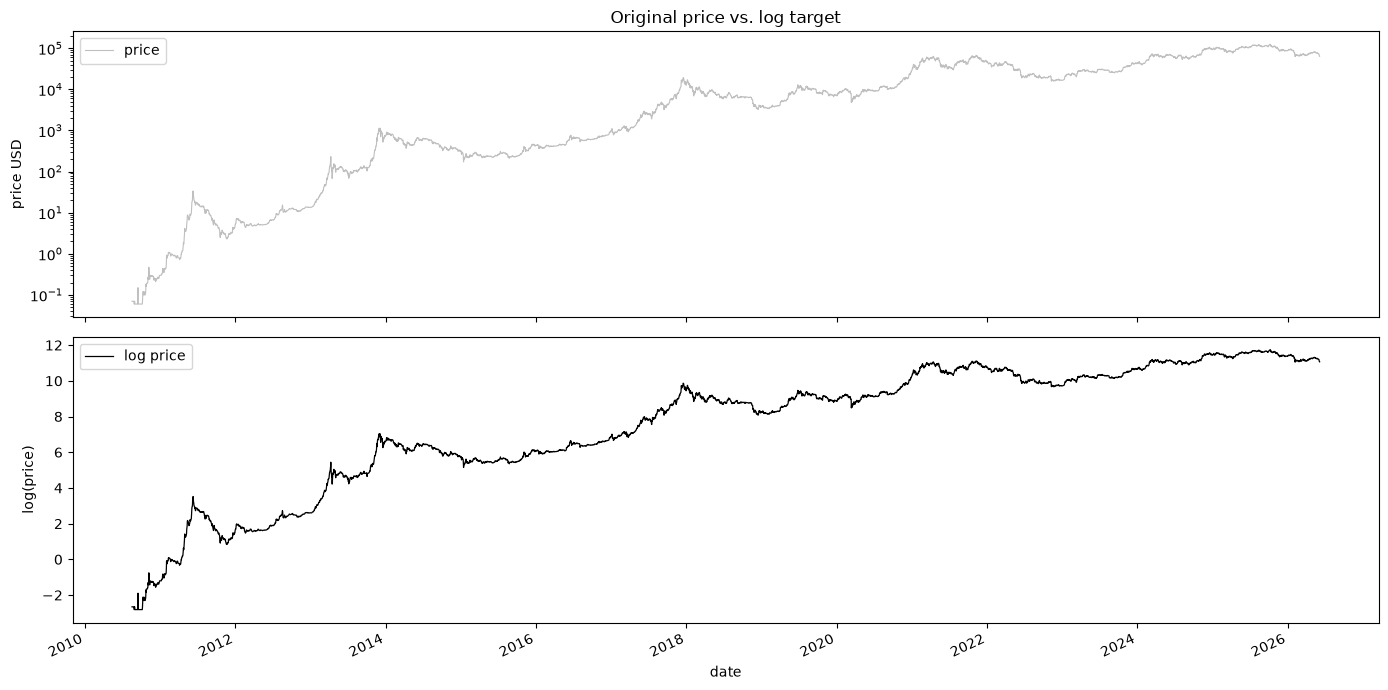

In [3]:
y = btc.log_price(price)
t = btc.normalized_time(n)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].semilogy(dates, price, color="0.75", lw=0.8, label="price")
axes[0].set_ylabel("price USD")
axes[0].legend()
axes[0].set_title("Original price vs. log target")

axes[1].plot(dates, y, "k", lw=0.9, label="log price")
axes[1].set_ylabel("log(price)")
axes[1].set_xlabel("date")
axes[1].legend()
btc.format_date_axis(axes[1], dates)
fig.tight_layout()
plt.show()


## Step 3: pull out the trend, then prefit the cycle on what's left

`analyze_log_trend()` fits and removes a log-trend from the training slice. Then `prefit(..., n_sines=1)` fits a single macro sine on the **residual**, using the five known macro peak years for phase alignment, rather than searching blind.


Train: 2010-08-18 to 2025-06-05 (n=5406)
Test:  2025-06-06 to 2026-06-05 (n=365)


omega=5.0  phase=0.103  time_scale=0.9061


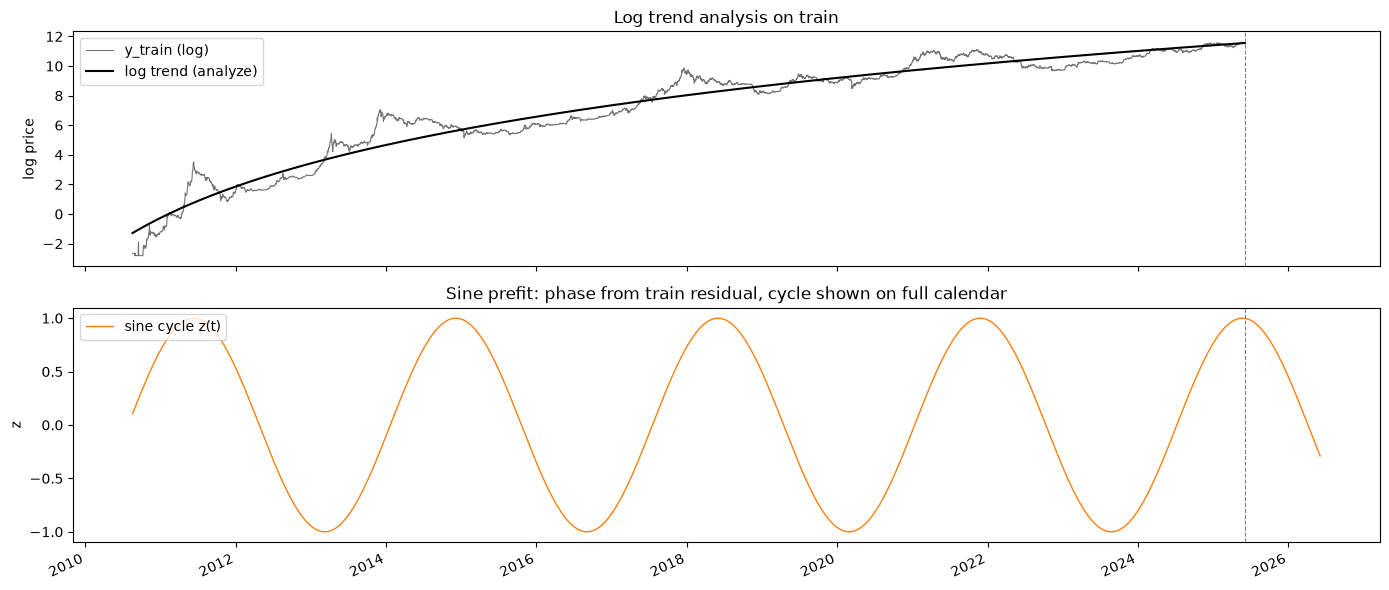

In [4]:
t_idx = btc.day_index(n)
split = btc.split_bitcoin_holdout(n, test_days=btc.TEST_DAYS, dates=dates)
train_idx, test_idx = split["train_idx"], split["test_idx"]
n_train = split["n_train"]
y_tr, y_te = y[train_idx], y[test_idx]
t_tr, t_te = t[train_idx], t[test_idx]
t_idx_tr = t_idx[train_idx]
dates_tr, dates_te = split["dates_train"], split["dates_test"]

print(f"Train: {dates_tr[0].date()} to {dates_tr[-1].date()} (n={n_train})")
print(f"Test:  {dates_te[0].date()} to {dates_te[-1].date()} (n={split['n_test']})")

prep = analyze_log_trend(y_tr, t_idx_tr)
peak_idx = btc.detect_btc_cycle_peaks(y_tr, dates_tr)
pf = prefit(
    prep.residual,
    t_tr,
    n_sines=1,
    peak_idx=peak_idx,
    omega=float(btc.N_CYCLE_PEAKS),
    envelope_init=True,
    t_full=t,
)
trend_pre = prep.trend
sine_fit = pf.sine_fit
z_pre = sine_fit["z"]
z_full = sine_fit["z_full"]
sine_fit_full = {**sine_fit, "z": z_full[:n_train]}

print(f"omega={sine_fit['omega']:.1f}  phase={sine_fit['phase']:.3f}  time_scale={sine_fit['time_scale']:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax0, ax1 = axes
ax0.plot(dates_tr, y_tr, color="0.45", lw=0.8, label="y_train (log)")
ax0.plot(dates_tr, trend_pre, color="black", lw=1.5, label="log trend (analyze)")
ax0.axvline(dates_tr[-1], color="gray", ls="--", lw=0.8)
ax0.set_ylabel("log price")
ax0.set_title("Log trend analysis on train")
ax0.legend(loc="upper left")
ax1.plot(dates, z_full, color="C1", lw=1.0, label="sine cycle z(t)")
ax1.axvline(dates_tr[-1], color="gray", ls="--", lw=0.8)
ax1.set_ylabel("z")
ax1.set_title("Sine prefit: phase from train residual, cycle shown on full calendar")
ax1.legend(loc="upper left")
btc.format_date_axis(ax1, dates)
fig.tight_layout()
plt.show()


## Step 4: fit the warp path and MLP observation model

Jointly learn the B-spline knot values for `p(i)` and a small MLP observation model on the warped sine, on train data only. `fit_lambda=0.5` matches the other examples (equal weight on fit and terror).


lambda          = 0.5
epochs          = 24000
path_anchor     = start
R2 (train)      = 0.9859
RMSE (train)    = 0.4056
sigma_y         = 0.4152
sigma_t         = 0.1712
sigma_index     = 4.7575
max offset      = 366.9 days
start-pin: p[0]=0.000  offset[0]=0.0000  terminal_offset=-98.7158


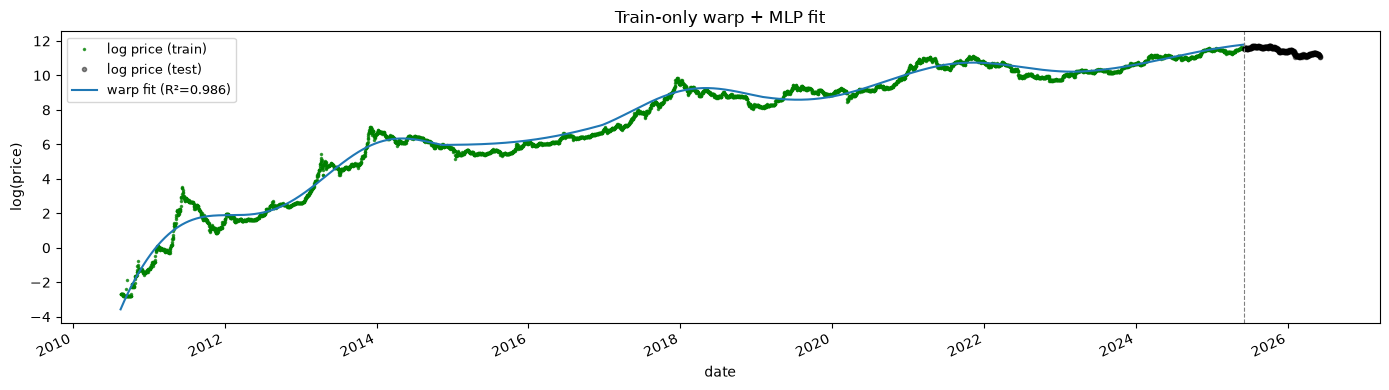

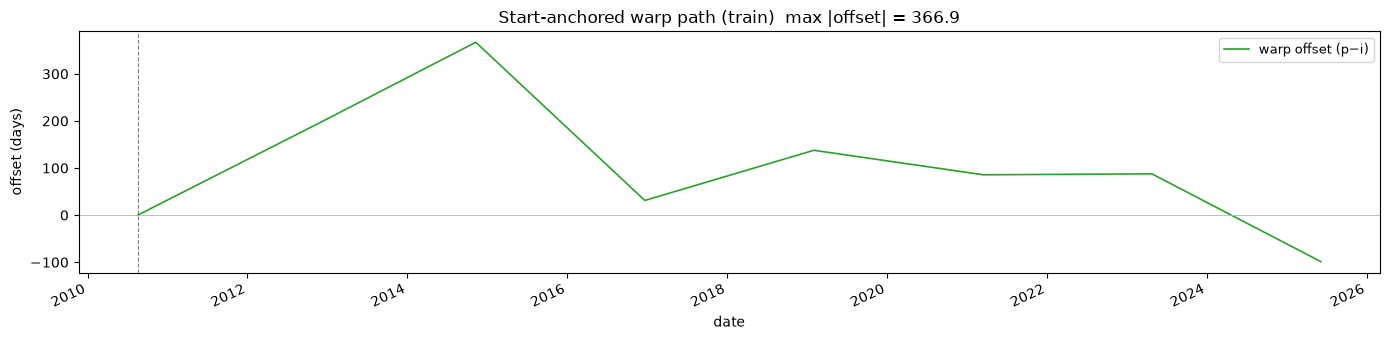

In [5]:
from warp_regression import WarpModel, per_index_rw_sigma

model = WarpModel.from_yaml(
    "bitcoin.yaml",
    overrides={
        "train": {
            "epochs": btc.EPOCHS,
            "lr": btc.WARP_LR,
            "fit_lambda": btc.FIT_LAMBDA,
            "seed": 0,
        },
        "n_knots": btc.N_KNOTS,
    },
)
fit_res = model.fit(
    y_tr,
    covariates={"z": np.asarray(sine_fit_full["z"], dtype=np.float64)[:n_train]},
    calendar={"t_idx": t_idx_tr, "t_norm": t_tr},
    sine_fit=sine_fit_full,
)
fit = fit_res.fit
fit["y_hat"] = fit_res.y_hat
fit["r2"] = fit_res.r2
fit["rmse"] = fit_res.rmse
fit["sine_fit"] = sine_fit_full
fit["n_calendar"] = int(round(0.5 / float(t_tr[0]))) if len(t_tr) else n_train
fit["_y_test"] = y_te
fit["_model"] = model

y_hat = fit["y_hat"]
n_knots = fit["n_knots"]
p_tr = fit["warp"]["p"]
off_tr = stored_path_offset_numpy(p_tr)
print(f"lambda          = {btc.FIT_LAMBDA}")
print(f"epochs          = {btc.EPOCHS}")
assert fit["warp"]["path_anchor"] == "start"
assert abs(float(p_tr[0])) < 1e-5 and abs(float(off_tr[0])) < 1e-5
print(f"path_anchor     = {fit['warp']['path_anchor']}")
print(f"R2 (train)      = {fit['r2']:.4f}")
print(f"RMSE (train)    = {fit['rmse']:.4f}")
print(f"sigma_y         = {fit['warp']['sigma_y']:.4f}")
print(f"sigma_t         = {fit['warp']['sigma_t']:.4f}")
print(f"sigma_index     = {per_index_rw_sigma(fit['warp']['sigma_t'], n_train, n_knots):.4f}")
print(f"max offset      = {fit['warp']['max_abs_offset']:.1f} days")
print(f"start-pin: p[0]={p_tr[0]:.3f}  offset[0]={off_tr[0]:.4f}  terminal_offset={off_tr[-1]:.4f}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates_tr, y_tr, "g.", ms=3, alpha=0.7, label="log price (train)")
ax.plot(dates_te, y_te, "ko", ms=3, alpha=0.45, label="log price (test)")
ax.plot(dates_tr, y_hat, color="C0", lw=1.5, label=f"warp fit (R²={fit['r2']:.3f})")
ax.axvline(split["train_end_date"], color="gray", ls="--", lw=0.8)
ax.set_title("Train-only warp + MLP fit")
ax.set_xlabel("date")
ax.set_ylabel("log(price)")
ax.legend(loc="upper left", fontsize=9)
btc.format_date_axis(ax, dates)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 3.5))
plot_warp_offset(
    ax, dates_tr, p_tr, anchor_x=dates_tr[0], color="C2",
    label="warp offset (p−i)",
    title=f"Start-anchored warp path (train)  max |offset| = {fit['warp']['max_abs_offset']:.1f}",
)
ax.set_ylabel("offset (days)")
ax.set_xlabel("date")
btc.format_date_axis(ax, dates)
fig.tight_layout()
plt.show()


## Step 5: forecast the holdout

Sample from the **fitted** start-pinned path (no prepare/refit). Early train knots stay at the MAP; the last train knot gets a terror-scale kick, then the usual knot RW continues. We then add a **residual MA** layer on top (flat level from the last `horizon` train residuals) and build two percentile bands at coverage `ci` (default 95%): **time-warp** and **total** (warp + iid $e_t$).


terminal_offset=-98.716  path_anchor=start  yhat_end=11.632 y_end=11.559
frozen σ_t=0.1712  σ_y=0.4152 (from fit)
residual MA: level=-0.1583  sigma=0.1353  horizon=365
Point forecast train/test corr = 0.994 / 0.350
Test RMSE (log) = 0.3360
CI nominal=95%  |  actual total=96.4%  |  actual warp=9.3%


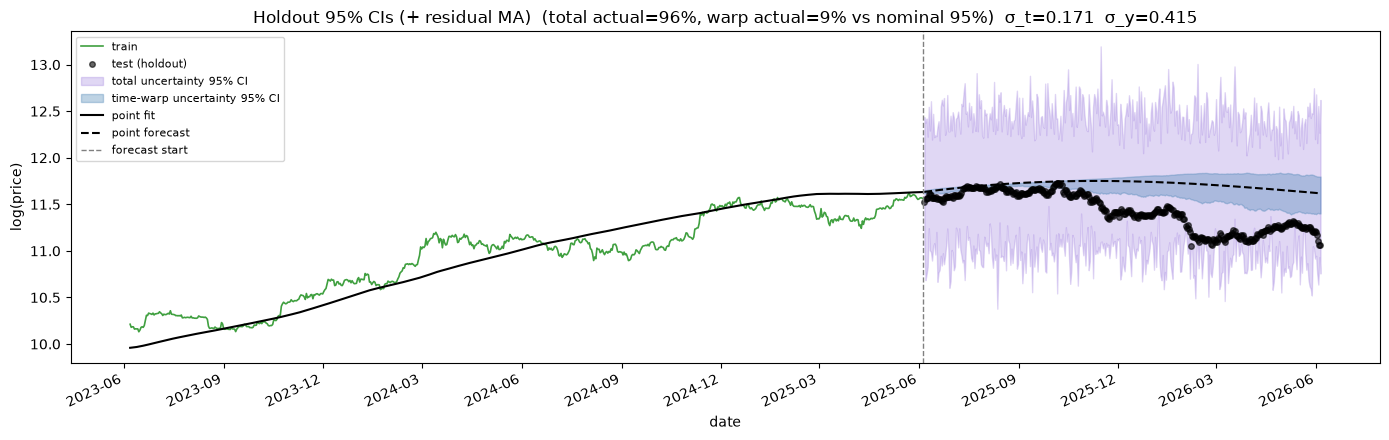

In [6]:
from warp_regression import (
    apply_residual_forecast,
    as_forecast_state,
    fit_residual_smooth,
    forecast_from_state,
)

ci = 0.95
n_show = btc.N_SINGLE_PATHS
hist_start = max(0, n_train - int(2 * 365.25))

state = as_forecast_state(
    fit, t_idx_full=t_idx, t_norm_full=t, z_full=z_full, n_obs=n_train
)
assert state.path_anchor == "start"
fc = forecast_from_state(
    state, n_future=split["n_test"], n_draws=n_show, n_paths_ci=n_show,
    seed=43, noise_seed=44, ci=ci,
)

# Residual MA on train residuals, then fold into the forecast (point + bands).
res_fit = fit_residual_smooth(y_tr - fit["y_hat"], horizon=split["n_test"])
fc = apply_residual_forecast(fc, res_fit, n_train, fc["sigma_y"], noise_seed=44)
bands = fc["bands"]
y_point = fc["y_point"]

cov_total = interval_coverage(y_te, bands["c_q_lo"][test_idx], bands["c_q_hi"][test_idx])
cov_warp = interval_coverage(y_te, bands["t_q_lo"][test_idx], bands["t_q_hi"][test_idx])
ci_pct = int(round(100 * ci))

print(
    f"terminal_offset={fc.get('terminal_offset', float('nan')):.3f}  "
    f"path_anchor={state.path_anchor}  "
    f"yhat_end={y_point[n_train-1]:.3f} y_end={y_tr[-1]:.3f}"
)
print(f"frozen σ_t={fc['sigma_t']:.4f}  σ_y={fc['sigma_y']:.4f} (from fit)")
print(
    f"residual MA: level={res_fit.level:+.4f}  sigma={res_fit.sigma:.4f}  "
    f"horizon={res_fit.horizon}"
)
print(
    f"Point forecast train/test corr = "
    f"{np.corrcoef(y_point[:n_train], y_tr)[0, 1]:.3f} / "
    f"{np.corrcoef(y_point[test_idx], y_te)[0, 1]:.3f}"
)
print(f"Test RMSE (log) = {np.sqrt(np.mean((y_point[test_idx] - y_te) ** 2)):.4f}")
print(
    f"CI nominal={ci:.0%}  |  actual total={cov_total:.1%}  |  actual warp={cov_warp:.1%}"
)

bands_test = {k: bands[k][test_idx] for k in ("t_q_lo", "t_q_hi", "c_q_lo", "c_q_hi")}
bands_test["ci"] = ci

fig, ax = plt.subplots(figsize=(14, 4.5))
plot_forecast_bands(
    ax,
    dates[hist_start:n_train],
    y[hist_start:n_train],
    dates_te,
    bands_test,
    x_test=dates_te,
    y_test=y_te,
    point_lines=[
        (dates[hist_start:n_train], y_point[hist_start:n_train], {"color": "black", "lw": 1.5, "label": "point fit"}),
        (dates_te, y_point[test_idx], {"color": "black", "lw": 1.5, "ls": "--", "label": "point forecast"}),
    ],
    forecast_start_x=split["train_end_date"],
    train_label="train",
    test_label="test (holdout)",
    ylabel="log(price)",
    xlabel="date",
    title=(
        f"Holdout {ci_pct}% CIs (+ residual MA)  "
        f"(total actual={cov_total:.0%}, warp actual={cov_warp:.0%} vs nominal {ci_pct}%)  "
        f"σ_t={fc['sigma_t']:.3f}  σ_y={fc['sigma_y']:.3f}"
    ),
)
btc.format_date_axis(ax, dates[hist_start:])
fig.tight_layout()
plt.show()


## Step 6: the 5-year forecast

Refit on the full series, push a 5-year forecast with the same start-pinned sampler, and again fold in the residual MA layer. Plots show the **full training history** for context, then the forward bands.


Full-series presize + warp fit for 5-year forecast


Full-series R2 = 0.9880  sigma_y = 0.3779  sigma_t = 0.1712
path_anchor=start  p[0]=0.000  terminal_offset=68.603
terminal_offset=68.603  yhat_end=11.463 y_end=11.064
frozen σ_t=0.1712  σ_y=0.3779 (from fit)
residual MA: level=+0.0963  sigma=0.2035  horizon=1826
Forecast horizon: 2026-06-05 to 2031-06-05  (1826 days)
Point forecast at +5yr (log) = 12.628  price ~ $305,065


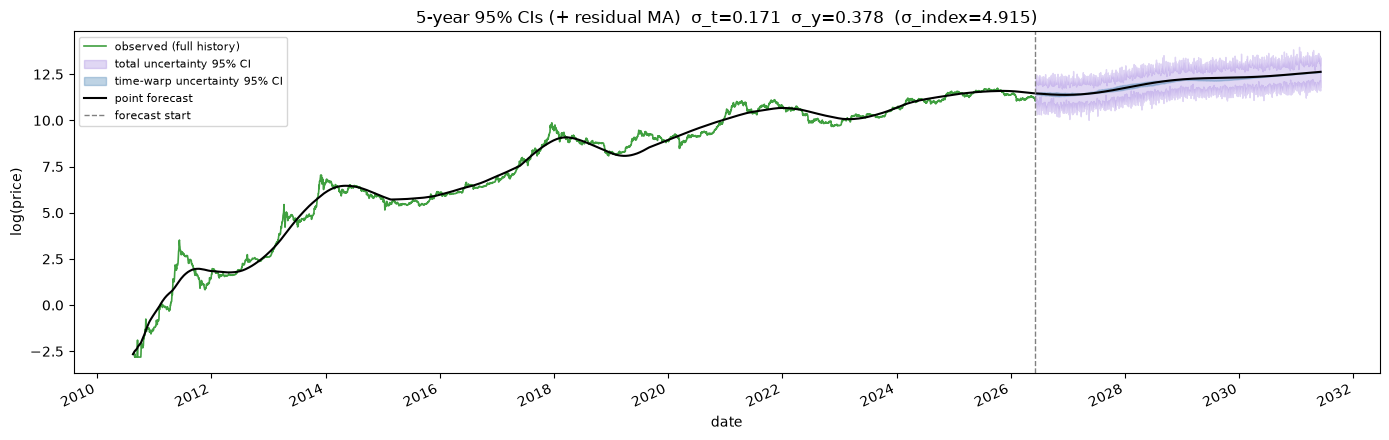

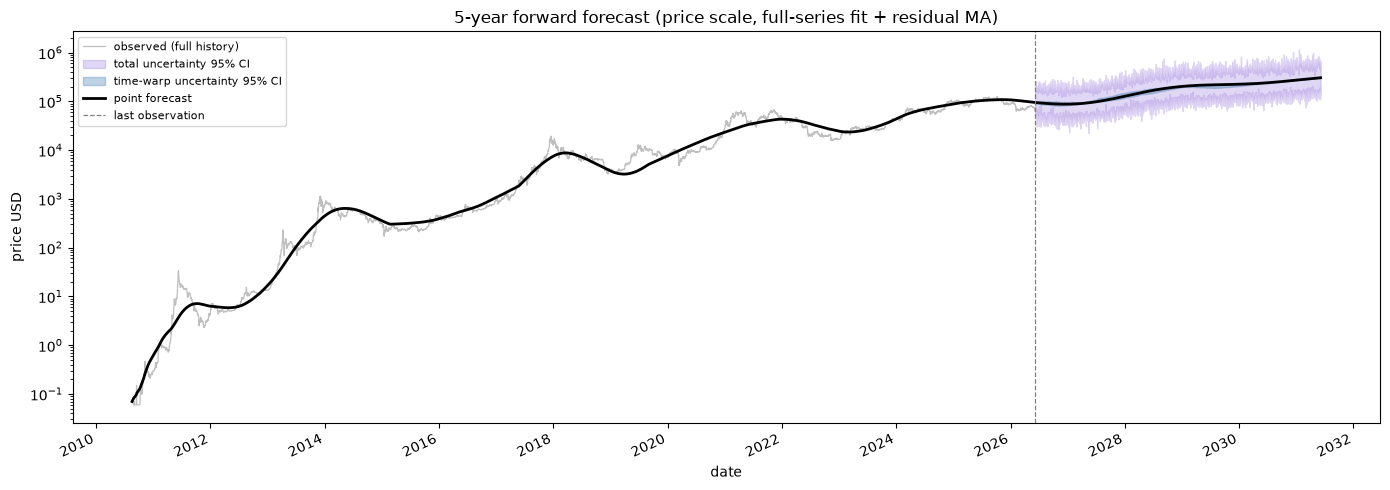

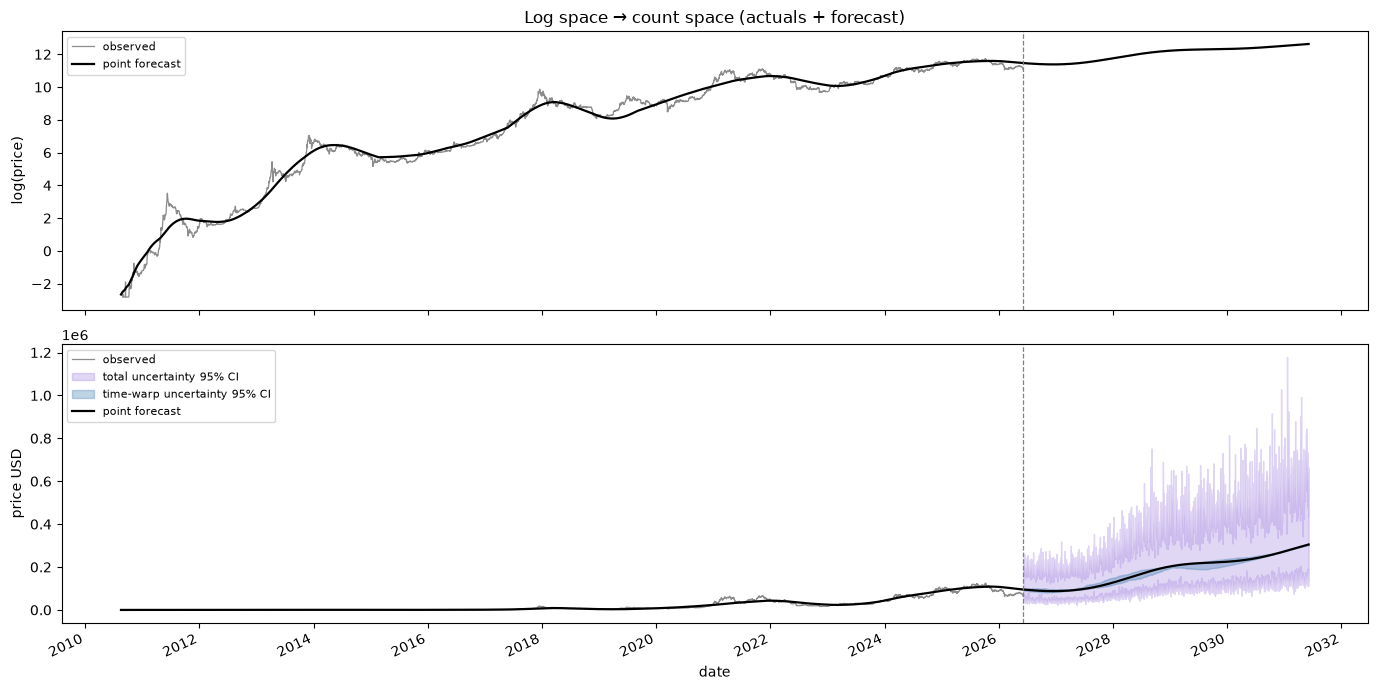

In [7]:
print("Full-series presize + warp fit for 5-year forecast")
prep_all = analyze_log_trend(y, t_idx)
peak_all = btc.detect_btc_cycle_peaks(y, dates)
pf_all = prefit(
    prep_all.residual, t, n_sines=1, peak_idx=peak_all,
    omega=float(btc.N_CYCLE_PEAKS), envelope_init=True, t_full=t,
)
sine_fit_all = pf_all.sine_fit
z_all = sine_fit_all["z_full"]
sine_fit_all_obs = {**sine_fit_all, "z": z_all}

model_full = WarpModel.from_yaml(
    "bitcoin.yaml",
    overrides={
        "train": {
            "epochs": btc.EPOCHS,
            "lr": btc.WARP_LR,
            "fit_lambda": btc.FIT_LAMBDA,
            "seed": 0,
        },
        "n_knots": btc.N_KNOTS,
    },
)
fit_full_res = model_full.fit(
    y,
    covariates={"z": np.asarray(sine_fit_all_obs["z"], dtype=np.float64)[:n]},
    calendar={"t_idx": t_idx, "t_norm": t},
    sine_fit=sine_fit_all_obs,
)
fit_full = fit_full_res.fit
fit_full["y_hat"] = fit_full_res.y_hat
fit_full["r2"] = fit_full_res.r2
fit_full["rmse"] = fit_full_res.rmse
fit_full["sine_fit"] = sine_fit_all_obs
fit_full["n_calendar"] = int(round(0.5 / float(t[0]))) if len(t) else n
fit_full["_model"] = model_full
n_knots_full = fit_full["n_knots"]
p_full = fit_full["warp"]["p"]
print(
    f"Full-series R2 = {fit_full['r2']:.4f}  "
    f"sigma_y = {fit_full['warp']['sigma_y']:.4f}  sigma_t = {fit_full['warp']['sigma_t']:.4f}"
)
print(
    f"path_anchor={fit_full['warp'].get('path_anchor', 'start')}  "
    f"p[0]={p_full[0]:.3f}  terminal_offset={stored_path_offset_numpy(p_full)[-1]:.3f}"
)

n_future_5 = btc.FORECAST_5YR_DAYS
t_ext, t_idx_ext, z_ext, n_total_5 = btc.build_forecast_extension(n, n_future_5, sine_fit_all)
dates_ext = pd.date_range(dates[0], periods=n_total_5, freq="D")
dates_fut_5 = dates_ext[n:]

state5 = as_forecast_state(
    fit_full, t_idx_full=t_idx_ext, t_norm_full=t_ext, z_full=z_ext, n_obs=n
)
assert state5.path_anchor == "start"
fc5 = forecast_from_state(
    state5, n_future=n_future_5, n_draws=n_show, n_paths_ci=n_show,
    seed=101, noise_seed=102, ci=ci,
)
res_fit5 = fit_residual_smooth(y - fit_full["y_hat"], horizon=n_future_5)
fc5 = apply_residual_forecast(fc5, res_fit5, n, fc5["sigma_y"], noise_seed=102)
bands5 = fc5["bands"]
y_point5 = fc5["y_point"]

fut_sl = np.arange(n, n_total_5)
print(
    f"terminal_offset={fc5.get('terminal_offset', float('nan')):.3f}  "
    f"yhat_end={y_point5[n-1]:.3f} y_end={y[-1]:.3f}"
)
print(f"frozen σ_t={fc5['sigma_t']:.4f}  σ_y={fc5['sigma_y']:.4f} (from fit)")
print(
    f"residual MA: level={res_fit5.level:+.4f}  sigma={res_fit5.sigma:.4f}  "
    f"horizon={res_fit5.horizon}"
)
print(f"Forecast horizon: {dates[-1].date()} to {dates_fut_5[-1].date()}  ({n_future_5} days)")
print(f"Point forecast at +5yr (log) = {y_point5[-1]:.3f}  price ~ ${np.exp(y_point5[-1]):,.0f}")

bands5_fut = {k: bands5[k][fut_sl] for k in ("t_q_lo", "t_q_hi", "c_q_lo", "c_q_hi")}
bands5_fut["ci"] = ci
ci_pct = int(round(100 * ci))

# Full training history + forward CIs (log scale)
fig, ax = plt.subplots(figsize=(14, 4.5))
plot_forecast_bands(
    ax, dates, y, dates_fut_5, bands5_fut,
    point_lines=[
        (dates_ext, y_point5, {"color": "black", "lw": 1.5, "label": "point forecast"}),
    ],
    forecast_start_x=dates[-1],
    train_label="observed (full history)",
    xlabel="date", ylabel="log(price)",
    title=(
        f"5-year {ci_pct}% CIs (+ residual MA)  "
        f"σ_t={fc5['sigma_t']:.3f}  σ_y={fc5['sigma_y']:.3f}  "
        f"(σ_index={per_index_rw_sigma(fc5['sigma_t'], n, n_knots_full):.3f})"
    ),
)
btc.format_date_axis(ax, dates_ext)
fig.tight_layout()
plt.show()

# Full history on price scale
fig, ax = plt.subplots(figsize=(14, 5))
ax.semilogy(dates, price, color="0.75", lw=0.9, label="observed (full history)")
ax.fill_between(
    dates_fut_5, np.exp(bands5["c_q_lo"][fut_sl]), np.exp(bands5["c_q_hi"][fut_sl]),
    color="mediumpurple", alpha=0.28, label=f"total uncertainty {ci_pct}% CI",
)
ax.fill_between(
    dates_fut_5, np.exp(bands5["t_q_lo"][fut_sl]), np.exp(bands5["t_q_hi"][fut_sl]),
    color="steelblue", alpha=0.35, label=f"time-warp uncertainty {ci_pct}% CI",
)
ax.semilogy(dates_ext, np.exp(y_point5), "k", lw=2, label="point forecast")
ax.axvline(dates[-1], color="gray", ls="--", lw=0.9, label="last observation")
ax.set_ylabel("price USD")
ax.set_xlabel("date")
ax.set_title("5-year forward forecast (price scale, full-series fit + residual MA)")
ax.legend(fontsize=8, loc="upper left")
btc.format_date_axis(ax, dates_ext)
fig.tight_layout()
plt.show()

# Log space → count (price) space: actuals + point forecast (+ both CIs on count)
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(dates, y, color="0.55", lw=0.9, label="observed")
axes[0].plot(dates_ext, y_point5, "k", lw=1.6, label="point forecast")
axes[0].axvline(dates[-1], color="gray", ls="--", lw=0.9)
axes[0].set_ylabel("log(price)")
axes[0].set_title("Log space → count space (actuals + forecast)")
axes[0].legend(fontsize=8, loc="upper left")

axes[1].plot(dates, price, color="0.55", lw=0.9, label="observed")
axes[1].fill_between(
    dates_fut_5, np.exp(bands5["c_q_lo"][fut_sl]), np.exp(bands5["c_q_hi"][fut_sl]),
    color="mediumpurple", alpha=0.28, label=f"total uncertainty {ci_pct}% CI",
)
axes[1].fill_between(
    dates_fut_5, np.exp(bands5["t_q_lo"][fut_sl]), np.exp(bands5["t_q_hi"][fut_sl]),
    color="steelblue", alpha=0.35, label=f"time-warp uncertainty {ci_pct}% CI",
)
axes[1].plot(dates_ext, np.exp(y_point5), "k", lw=1.6, label="point forecast")
axes[1].axvline(dates[-1], color="gray", ls="--", lw=0.9)
axes[1].set_ylabel("price USD")
axes[1].set_xlabel("date")
axes[1].legend(fontsize=8, loc="upper left")
btc.format_date_axis(axes[1], dates_ext)
fig.tight_layout()
plt.show()


## Step 7: how long until the next halving-cycle peak?

Same trick as the last two notebooks: continue warp paths forward with the fitted $\sigma_t$ and measure the spacing to the next peak of the warped macro sine. The dashed line is the *nominal* cycle length $n/\omega$ on the training calendar: what you'd get if the cycle were perfectly regular.


Nominal cycle ≈ 1308 days  |  sample median = 1384 days  |  σ_t = 0.171


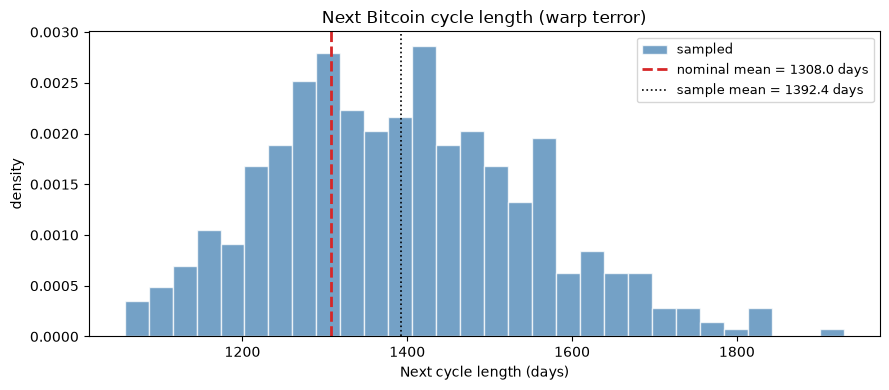

In [8]:
from warp_regression import analyze_cycle_lengths, plot_cycle_length_distribution

cyc = analyze_cycle_lengths(
    fit=fit_full,
    sine_fit=sine_fit_all,
    n_calendar=n,
    unit="days",
    n_paths=500,
    seed=7,
)
fig, ax = plt.subplots(figsize=(9, 4))
plot_cycle_length_distribution(cyc, ax=ax, title="Next Bitcoin cycle length (warp terror)")
print(
    f"Nominal cycle ≈ {cyc.mean_cycle_length:.0f} days  |  "
    f"sample median = {np.median(cyc.lengths):.0f} days  |  "
    f"σ_t = {cyc.sigma_t:.3f}"
)
fig.tight_layout()
plt.show()


## Wrapping up

| Step | What happened |
|------|----------------|
| 1–2 | Loaded daily BTC prices, moved to log space |
| 3 | Removed the log-trend, prefit a macro sine on the residual using known peak years |
| 4 | Fit the start-anchored warp path + MLP observation model on train only (λ=0.5) |
| 5 | Forecast the 365-day holdout with time-warp + total 95% bands, including residual MA |
| 6 | Refit on the full series, 5-year forecast with residual MA (full history shown) |
| 7 | Distribution over the next cycle's length |

That's three notebooks so far: a clean synthetic example to see the mechanics, a real ecological series to stress-test it with multiple cycles and nonlinear observation models, and a financial series with a dominant trend and a single macro cycle. Same core idea throughout: a known-shape cycle, a start-anchored warp path with its own likelihood, and forecast uncertainty that comes directly from sampling that likelihood forward in time.

Next: **Sunspots**, where the cycle is astrophysical rather than economic or ecological, and the monthly record runs continuously back to 1749.
